# Q1: Supervised Learning – Heart Disease Prediction

## 1. Data Loading and Inspection

In [1]:
import pandas as pd

df = pd.read_csv('../data/q1_heart_disease.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    object 
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    object 
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    object 
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 75.1+ KB


The dataset consists of 800 rows and 12 columns.

Using df.info() command, we are able to see types of features that have been used to construct this data set. A mix of numerical (int64 and float64) and categorical (object) data are present.

There are missing values for some columns (resting_bp and cholesterol). These will need to be handled in the data preprocessing step.

The dataset contains a mix of numerical (health related) variables and factors and also the target variable for heart disease prediction, which is classified as categorical.

In [3]:
df.describe()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease
count,800.000000,800.000000,776.000000,768.000000,800.00000,800.000000,800.000000,800.000000,800.000000
mean,52.191250,0.665000,130.668814,245.622396,0.23250,149.145000,0.295000,0.925500,0.508750
std,12.862211,0.472286,16.408805,52.185464,0.42269,22.396394,0.456328,0.897612,0.500236
min,30.000000,0.000000,90.000000,120.000000,0.00000,76.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,120.000000,209.000000,0.00000,134.000000,0.000000,0.300000,0.000000
50%,53.000000,1.000000,130.000000,247.000000,0.00000,149.000000,0.000000,0.600000,1.000000
75%,63.000000,1.000000,142.000000,279.250000,0.00000,165.000000,1.000000,1.300000,1.000000
max,74.000000,1.000000,184.000000,420.000000,1.00000,202.000000,1.000000,5.700000,1.000000


The average age of the patients involved was 52 years (30-74). The average blood pressure and cholesterol readings also varied. Please note that some of these values are possibly outliers.

Based on the health of the patient, Maximum heart rate can vary widely, ranging from 76 to 202.

These quartile values (25%, 50%, 75%) provide information on data dispersion and central tendency, expressing the changes in values among patients.

These statistics provide further detail on variability within the distribution, on potential outliers, and on the shape of the distribution of several critical health indicators.

In [4]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


The dataset contains missing values in two numerical columns: resting_bp and cholesterol.

resting_bp has 24 missing values and cholesterol has 32 missing values, while all other columns have complete data.

Since these are numerical features and may contain outliers, the missing values will be handled using median imputation in the preprocessing step, as the median is more robust to extreme values than the mean.

## 2. Exploratory Data Analysis

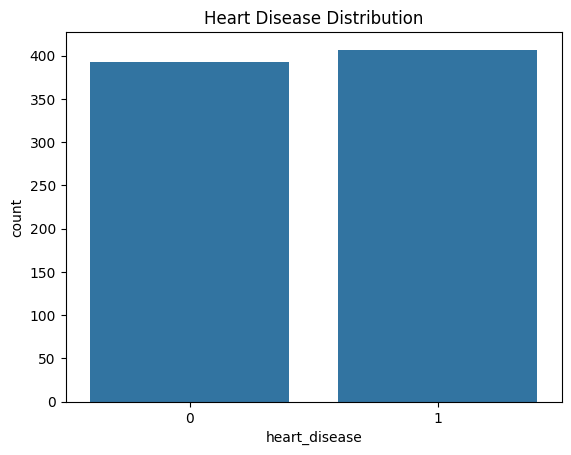

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

The target variable (heart_disease) is almost evenly distributed between the two classes, with a similar number of patients having heart disease (1) and not having heart disease (0).

This balanced distribution is advantageous for classification models, as it reduces the risk of bias toward a particular class and helps the model learn patterns for both classes effectively.

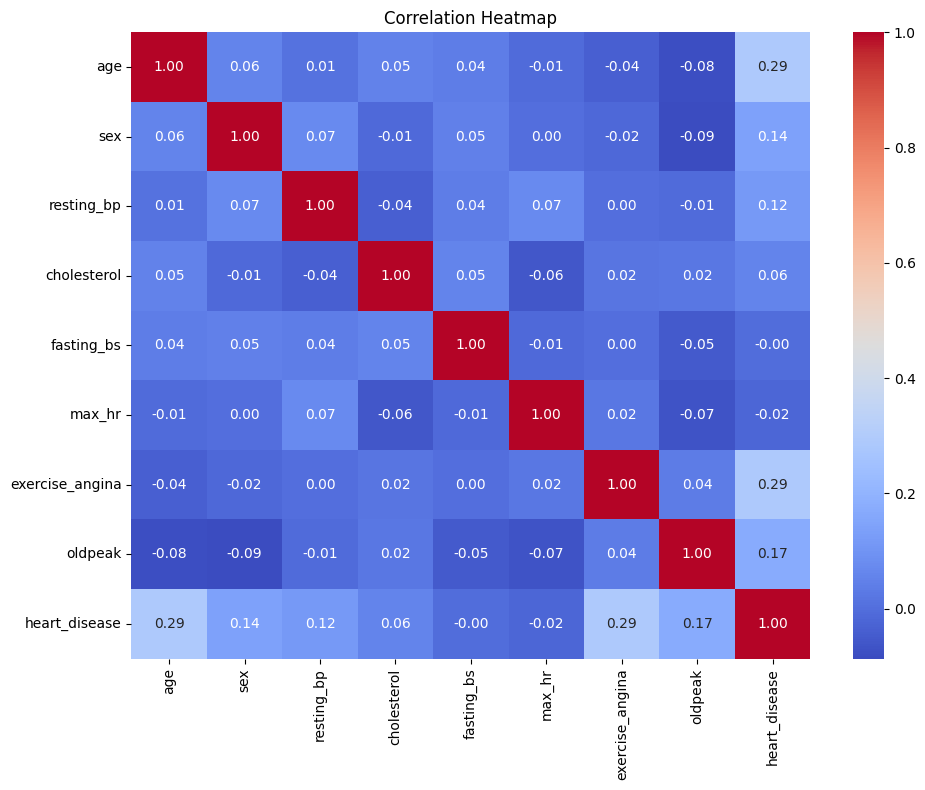

In [6]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap of correlations shows relationships between the numerical features in the dataset.

The features that correlate most with heart_disease are age, exercise_angina and oldpeak. exercise_exertion_oldpeak shows a very weak correlation.

With the exception of a few features, the correlations between most feature pairs are low, suggesting that multicollinearity is not a major issue in this dataset.

The findings of this work suggest that a number of different features jointly may be more predictive of heart disease than a very strong single feature.

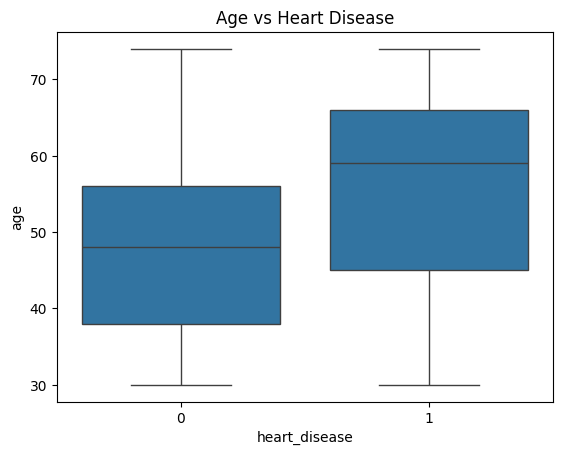

In [7]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

The boxplots show that patients with heart disease (1) are generally older than those without heart disease (0).

The median age for patients with heart disease is higher, however there is a positive correlation between age and heart disease.

This suggests that age is an important feature and may play a significant role in predicting heart disease.

## 3. Data Preprocessing

In [8]:
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholesterol,0
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


Missing values in the resting_bp and cholesterol columns were handled using median imputation.

resting_bp had 24 missing values and cholesterol had 32 missing values, which have been successfully filled, as the null values is absent in the dataset.

For handling missing values in numerical features, median imputation was used because it is significantly more robust to outliers than mean imputation.

In [9]:
df = pd.get_dummies(df, drop_first=True)
df = df.astype(int)
df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142,399,0,169,0,0,1,1,0,0,0,0,0,1
1,58,1,163,310,1,121,1,1,1,0,1,0,0,1,0,1
2,44,1,128,175,0,183,1,0,0,0,1,0,1,0,0,1
3,72,1,114,177,0,150,0,1,1,0,0,0,0,1,0,1
4,37,1,149,271,0,136,0,0,0,0,1,0,1,0,1,0


Categorical variables such as chest_pain_type, resting_ecg, and st_slope were converted into numerical format using one-hot encoding.

This process creates binary indicator variables for each category, allowing machine learning models to interpret categorical data effectively.

We used drop_first=True to remove a redundant category from each feature, which helped to prevent multicollinearity and offered more stable performance.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale AFTER split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (640, 15)
Test: (160, 15)


The dataset was split into training and testing sets using an 80-20 ratio.

Stratified sampling applied to ensure that the proportion of patients with and without heart disease remains consistent in both the training and testing sets. This helps the model learn balanced patterns from the data.

After splitting, feature scaling was performed using StandardScaler. The scaler was fitted only on the training data and then applied to both the training and test sets.

This approach avoids data leakage, ensuring that the training process is not influence by information from the test set, and leads to more reliable evaluation of the model.

Feature scaling is important because many machine learning algorithms are sensitive to the scale of input features, and standardizing them helps improve model performance.

## 4. Model Training

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.68125

Confusion Matrix:
[[55 24]
 [27 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.70      0.68        79
           1       0.69      0.67      0.68        81

    accuracy                           0.68       160
   macro avg       0.68      0.68      0.68       160
weighted avg       0.68      0.68      0.68       160



A Decision Tree Classifier was trained to predict heart disease.

The model achieved an accuracy of approximately 68.1% on the test set. Decision Trees are easy to interpret and can capture non-linear relationships, but they may overfit the data.

The confusion matrix and classification report provide additional evaluation using precision, recall, and F1-score.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7625

Confusion Matrix:
[[58 21]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75        79
           1       0.75      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160



A Random Forest Classifier was trained using an ensemble of decision trees to improve prediction accuracy.

The model achieved an accuracy of approximately 76.3% on the test set, which is higher compare to the Decision Tree model.

Random Forest reduces overfitting by averaging multiple trees and generally provides better generalization performance.

The confusion matrix and classification report further evaluate the model using precision, recall, and F1-score, providing a more detailed understanding of performance.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.76875

Confusion Matrix:
[[59 20]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



A Gradient Boosting Classifier was trained to improve model performance by combining multiple weak learners sequentially.

The model achieved an accuracy of approximately 76.9% on the test set, performing better than the Decision Tree model and slightly better than the Random Forest model.

The confusion matrix and the classification report provide a more detailed view of the model’s performance including parameters like precision, recall and F1-score for both classes, indicating balanced performance.

## 5. Model Evaluation

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print("\n", name)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


 Decision Tree
Confusion Matrix:
[[55 24]
 [27 54]]
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.70      0.68        79
           1       0.69      0.67      0.68        81

    accuracy                           0.68       160
   macro avg       0.68      0.68      0.68       160
weighted avg       0.68      0.68      0.68       160


 Random Forest
Confusion Matrix:
[[58 21]
 [17 64]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75        79
           1       0.75      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160


 Gradient Boosting
Confusion Matrix:
[[59 20]
 [17 64]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
     

### Best Model Analysis

Based on the evaluation metrics, the Gradient Boosting Classifier was the best performing model of the three.

The approach reached the highest accuracy of about 77% with balanced precision, recall and F1-score for both classes.

The Decision Tree performed the poorest with the lowest accuracy as well as lowest metrics overall. This was followed by the Random Forest results, which performed better than the Decision Tree, however slightly worse than the Gradient Boosting results.

Therefore, Gradient Boosting is the best model for predicting heart disease in this dataset.

### 6. Hyperparameter Tuning


In [15]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Tuned Model Accuracy: 0.76875


The best parameters were learning_rate=0.05, max_depth=5, and n_estimators=100.

The tuned Gradient Boosting model achieved an accuracy of approximately 76.9%, as same as the untuned Gradient Boosting baseline.

This indicates that hyperparameter tuning did not improve performance, but Gradient Boosting remains the best-performing model based on the evaluation metrics.